1.Mount the Google Drvie

In [27]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ValueError: Mountpoint must not already contain files

Folder Paths

In [1]:
import os

BASE_PATH = "/content/drive/MyDrive/DR_Project"
DATASET_ZIP = "/content/diabetic-retinopathy-dataset.zip"

EXTRACT_PATH = "/content/dataset"
BALANCED_PATH = BASE_PATH + "/balanced_dataset"
MODEL_PATH = BASE_PATH + "/models"

os.makedirs(BALANCED_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print("Folders ready")

Folders ready


3.Extract the diabetic-retinopathy dataset

In [2]:
import json, os

kaggle_json = {
    "username": "keer26",
    "key": "KGAT_78563d4fdf688ee7fa46af86b3809c18"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          22261        471                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           2427         57                1  
nuhmanpk/tamil-nadu-assembly-election-results-2026                  Tamil Nadu Assembly Election Results 2026                81483  2026-05-04 18:05:41.200000            504         22

In [5]:
!kaggle datasets download -d sachinkumar413/diabetic-retinopathy-dataset -p /content

Dataset URL: https://www.kaggle.com/datasets/sachinkumar413/diabetic-retinopathy-dataset
License(s): ODbL-1.0
100% 350M/350M [00:09<00:00, 39.4MB/s]



Image Preprocessing

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 224

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    enhanced = enhanced / 255.0
    return img, enhanced

Classes: ['Moderate DR', 'Proliferate DR', 'Healthy', 'Mild DR', 'Severe DR']


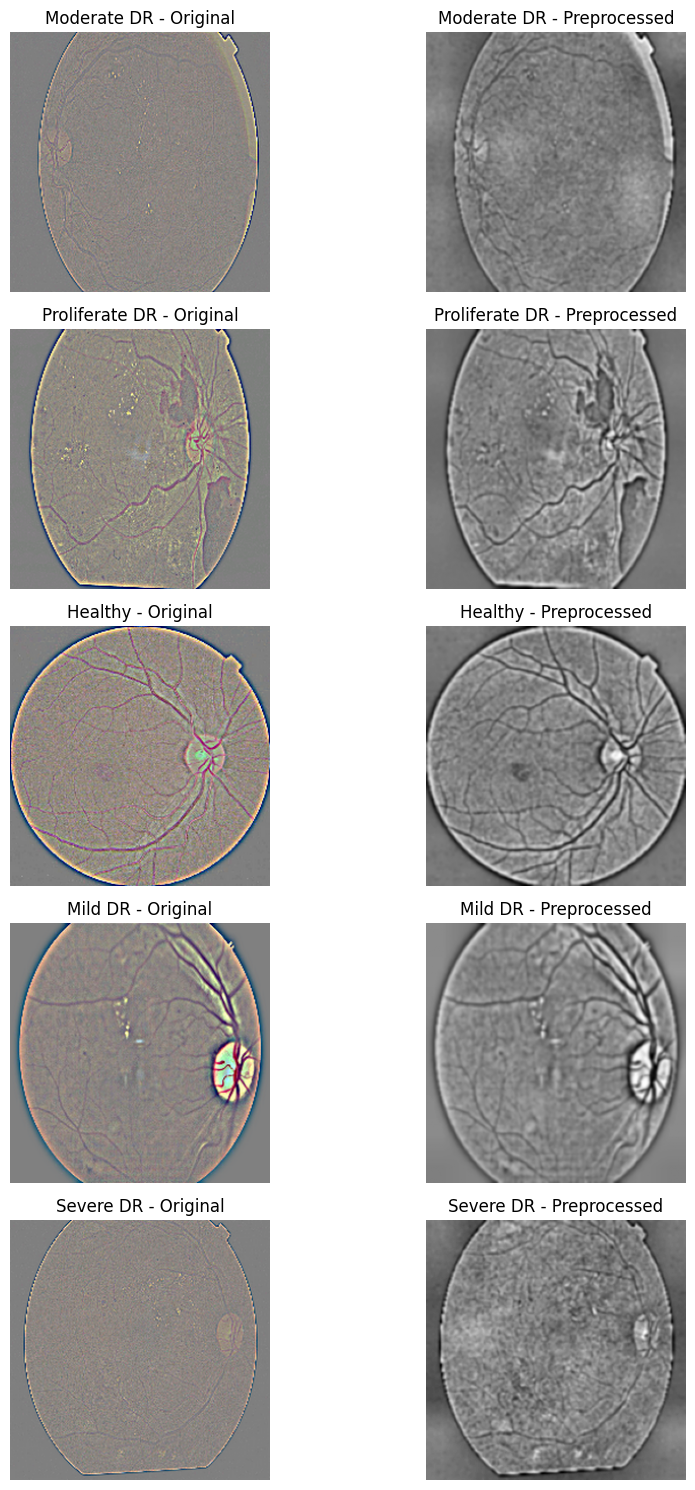

In [9]:
import os, random
import cv2
import matplotlib.pyplot as plt

# 🔹 Preprocessing function (final version only)
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(img, (224, 224))
    green = resized[:, :, 1]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(green)

    blurred = cv2.GaussianBlur(clahe_img, (5,5), 0)

    return img, blurred


# 🔹 Dataset path
dataset_path = "/content/dataset"

classes = [
    f for f in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, f))
]

print("Classes:", classes)

# 🔹 Plot for ALL classes
plt.figure(figsize=(10, 15))

for i, cls in enumerate(classes):
    class_dir = os.path.join(dataset_path, cls)

    # pick one random image per class
    img_name = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, img_name)

    original, processed = preprocess_image(img_path)

    # Original
    plt.subplot(len(classes), 2, 2*i + 1)
    plt.imshow(original)
    plt.title(f"{cls} - Original")
    plt.axis("off")

    # Processed
    plt.subplot(len(classes), 2, 2*i + 2)
    plt.imshow(processed, cmap='gray')
    plt.title(f"{cls} - Preprocessed")
    plt.axis("off")

plt.tight_layout()
plt.show()

Extract the loaded dataset

In [8]:
import zipfile

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted")

Dataset extracted


Copy Original Images to Balanced dataset Folder that is created

In [10]:
import shutil

for cls in os.listdir(EXTRACT_PATH):
    src = os.path.join(EXTRACT_PATH, cls)
    dst = os.path.join(BALANCED_PATH, cls)
    os.makedirs(dst, exist_ok=True)

    for img in os.listdir(src):
        src_file = os.path.join(src, img)
        dst_file = os.path.join(dst, img)
        if not os.path.exists(dst_file):
            shutil.copy(src_file, dst)

print("Original images copied")


Original images copied


Fast DDPM Settings

In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline
from torch import nn
from tqdm import tqdm
import glob

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 20
TIMESTEPS = 200


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Image Transform

In [12]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


Dual Attention Model

In [13]:
def get_model():
    model = UNet2DModel(
        sample_size=IMG_SIZE,
        in_channels=3,
        out_channels=3,
        layers_per_block=2,
        block_out_channels=(32, 64, 128),
        down_block_types=(
            "DownBlock2D",
            "AttnDownBlock2D",
            "DownBlock2D"
        ),
        up_block_types=(
            "UpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D"
        ),
    ).to(DEVICE)

    return model


Load Dataset for One Class

In [14]:
def get_class_loader(class_name):
    dataset = datasets.ImageFolder(EXTRACT_PATH, transform=transform)
    class_idx = dataset.class_to_idx[class_name]

    indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
    subset = Subset(dataset, indices)

    loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
    return loader


In [15]:
def load_latest_checkpoint(model, class_name):
    files = glob.glob(f"{MODEL_PATH}/ddpm_{class_name}_epoch_*.pth")
    if len(files) == 0:
        return 0

    latest = sorted(files)[-1]
    epoch_num = int(latest.split("_")[-1].split(".")[0])

    model.load_state_dict(torch.load(latest))
    print(f"Resumed from epoch {epoch_num}")

    return epoch_num + 1


Training

In [16]:
def train_ddpm(class_name):
    print(f"\nTraining {class_name}")

    loader = get_class_loader(class_name)
    model = get_model()
    scheduler = DDPMScheduler(num_train_timesteps=TIMESTEPS)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.MSELoss()

    start_epoch = load_latest_checkpoint(model, class_name)

    model.train()

    for epoch in range(start_epoch, EPOCHS):
        pbar = tqdm(loader)

        for images, _ in pbar:
            images = images.to(DEVICE)

            noise = torch.randn_like(images)
            timesteps = torch.randint(0, TIMESTEPS, (images.size(0),), device=DEVICE)

            noisy_images = scheduler.add_noise(images, noise, timesteps)
            noise_pred = model(noisy_images, timesteps).sample

            loss = loss_fn(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pbar.set_description(f"{class_name} Epoch {epoch} Loss {loss.item():.4f}")

        save_file = f"{MODEL_PATH}/ddpm_{class_name}_epoch_{epoch}.pth"
        torch.save(model.state_dict(), save_file)
        print("Saved:", save_file)

    return model, scheduler


Image Generation

In [17]:
def generate_images(model, scheduler, class_name, num_images):
    print(f"Generating {num_images} images for {class_name}")

    pipeline = DDPMPipeline(unet=model, scheduler=scheduler).to(DEVICE)

    save_path = os.path.join(BALANCED_PATH, class_name)
    os.makedirs(save_path, exist_ok=True)

    existing = len(os.listdir(save_path))

    for i in range(num_images):
        image = pipeline(num_inference_steps=100).images[0]
        image.save(f"{save_path}/synthetic_{existing+i}.png")

    print("Generation completed")


Generation plan

In [18]:
generate_plan = {
    "Proliferate DR":295 ,
    "Mild DR":137 ,
    "Moderate DR":900 ,
    "Severe DR":190
}

Generating Synthetic images for each class to make every class 1000 images

In [ ]:
class_name = "Mild"

model, scheduler = train_ddpm(class_name)
generate_images(model, scheduler, class_name, generate_plan[class_name])


Listing the no.of images in each class from balanced dataset

In [19]:
for cls in os.listdir(BALANCED_PATH):
    print(cls, len(os.listdir(os.path.join(BALANCED_PATH, cls))))


Moderate DR 900
Proliferate DR 290
Healthy 1000
Mild DR 370
Severe DR 190


Load Balanced dataset

In [20]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
from tqdm import tqdm


In [21]:
DATA_PATH = "/content/drive/MyDrive/DR_Project/balanced_dataset"
MODEL_PATH = "/content/drive/MyDrive/DR_Project/dr_classifier_bias_reduced.pth"


In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


In [23]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [24]:
dataset = datasets.ImageFolder(DATA_PATH, transform=transform)
classes = dataset.classes
num_classes = len(classes)
print("Class order:", classes)

Class order: ['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']


In [25]:
labels = [label for _, label in dataset.samples]
class_counts = Counter(labels)
total = sum(class_counts.values())


In [26]:
class_weights = [total / class_counts[i] for i in range(num_classes)]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: [2.75, 7.4324324324324325, 3.0555555555555554, 9.482758620689655, 14.473684210526315]


In [27]:
sample_weights = [class_weights[label] for label in labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
loader = DataLoader(dataset, batch_size=32, sampler=sampler, num_workers=2)

In [28]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


In [29]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [30]:
EPOCHS = 12  # more epochs improve bias correction
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    pbar = tqdm(loader)

    for images, labels_batch in pbar:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_description(f"Epoch {epoch+1} Loss {loss.item():.4f}")

    print(f"Epoch {epoch+1} Avg Loss: {running_loss/len(loader):.4f}")

Epoch 1 Loss 1.0191: 100%|██████████| 86/86 [00:19<00:00,  4.50it/s]


Epoch 1 Avg Loss: 0.9880


Epoch 2 Loss 0.7432: 100%|██████████| 86/86 [00:17<00:00,  5.04it/s]


Epoch 2 Avg Loss: 0.7565


Epoch 3 Loss 0.5501: 100%|██████████| 86/86 [00:17<00:00,  5.01it/s]


...

Epoch 10 Avg Loss: 0.2412


Epoch 11 Loss 0.4306: 100%|██████████| 86/86 [00:20<00:00,  4.22it/s]


Epoch 11 Avg Loss: 0.2143


Epoch 12 Loss 0.1474: 100%|██████████| 86/86 [00:18<00:00,  4.75it/s]

Epoch 12 Avg Loss: 0.2061


In [31]:
torch.save(model.state_dict(), MODEL_PATH)
print("Bias-reduced model saved at:", MODEL_PATH)


Bias-reduced model saved at: /content/drive/MyDrive/DR_Project/dr_classifier_bias_reduced.pth


In [32]:
pred_counts = {cls: 0 for cls in classes}
model.eval()
with torch.no_grad():
    for images, labels_batch in loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        for p in preds:
            pred_counts[classes[p]] += 1

max_count = max(pred_counts.values())
print("\nEstimated bias per class (Healthy bias should ~0.05):")
for cls in classes:
    bias_score = pred_counts[cls] / max_count
    print(f"{cls}: {bias_score:.2f} ({pred_counts[cls]} predictions)")


Estimated bias per class (Healthy bias should ~0.05):
Healthy: 0.86 (553 predictions)
Mild DR: 0.98 (626 predictions)
Moderate DR: 0.46 (297 predictions)
Proliferate DR: 1.00 (641 predictions)
Severe DR: 0.99 (633 predictions)


In [60]:
from sklearn.metrics import accuracy_score, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


acc = accuracy_score(all_labels, all_preds)
print("\nOverall Accuracy:", round(acc*100,2), "%")


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


Overall Accuracy: 91.75 %

Classification Report:
                precision    recall  f1-score   support

       Healthy       1.00      0.98      0.99       555
       Mild DR       0.91      0.97      0.94       557
   Moderate DR       0.95      0.73      0.83       566
Proliferate DR       0.90      0.92      0.91       537
     Severe DR       0.84      0.99      0.91       535

      accuracy                           0.92      2750
     macro avg       0.92      0.92      0.92      2750
  weighted avg       0.92      0.92      0.92      2750



In [61]:
def get_precautions(stage):

    precautions = {
        "Healthy": [
            "Maintain normal blood sugar levels",
            "Have annual eye checkups",
            "Follow healthy diet and exercise regularly",
            "Avoid smoking and alcohol"
        ],

        "Mild DR": [
            "Monitor blood sugar strictly",
            "Visit eye specialist every 6–12 months",
            "Control blood pressure and cholesterol",
            "Increase physical activity"
        ],

        "Moderate DR": [
            "Frequent retinal examinations (every 3–6 months)",
            "Strict diabetes control required",
            "Follow doctor-prescribed medication",
            "Avoid high sugar and processed foods"
        ],

        "Severe DR": [
            "Immediate consultation with ophthalmologist",
            "Strict glucose and BP control",
            "Possible laser treatment evaluation",
            "Do not ignore vision changes"
        ],

        "Proliferate DR": [
            "Urgent specialist consultation required",
            "Possible laser or injection treatment",
            "Monitor vision regularly",
            "Strict diabetes management is critical"
        ]
    }

    return precautions.get(stage, ["Consult doctor"])


In [62]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
img_name = list(uploaded.keys())[0]


image = Image.open(img_name).convert('RGB')
image = transform(image).unsqueeze(0).to(device)


with torch.no_grad():
    output = model(image)
    probs = torch.softmax(output, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()

stage = classes[pred_idx]

print("\nPredicted DR Stage:", stage)

print("\nClass Probabilities:")
for i, cls in enumerate(classes):
    print(f"{cls}: {probs[0][i].item():.4f}")

Saving Screenshot 2026-03-29 151935.png to Screenshot 2026-03-29 151935.png

Predicted DR Stage: Proliferate DR

Class Probabilities:
Healthy: 0.0017
Mild DR: 0.0020
Moderate DR: 0.0005
Proliferate DR: 0.9955
Severe DR: 0.0004


In [63]:
print("\nRecommended Precautions:")

for i, tip in enumerate(get_precautions(stage), 1):
    print(f"{i}. {tip}")



Recommended Precautions:
1. Urgent specialist consultation required
2. Possible laser or injection treatment
3. Monitor vision regularly
4. Strict diabetes management is critical


In [64]:
!pip install gradio

In [65]:
import gradio as gr
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

In [66]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [1]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)  # 5 classes

model = model.to(device)

MODEL_PATH = "/content/drive/MyDrive/DR_Project/dr_classifier_bias_reduced.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Model Loaded Successfully ✅")

NameError: name 'models' is not defined

In [47]:
classes = ['Healthy','Mild DR','Moderate DR','Proliferative DR','Severe DR']

precautions = {
    "Healthy":"Maintain healthy lifestyle and regular checkups.",
    "Mild DR":"Control blood sugar and yearly screening.",
    "Moderate DR":"Consult doctor regularly.",
    "Proliferative DR":"Urgent treatment needed.",
    "Severe DR":"Immediate medical attention required."

}

In [48]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [49]:
def predict(image):
    try:
        image = image.convert("RGB")

        x = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(x)
            pred = torch.argmax(output,1).item()

        stage = classes[pred]
        precaution = precautions[stage]

        return stage, precaution

    except Exception as e:
        return f"Error: {str(e)}", "Check model / input"

In [50]:
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Retinal Image"),
    outputs=[
        gr.Text(label="Predicted DR Stage"),
        gr.Text(label="Precautions")
    ],
    title="Diabetic Retinopathy Detection System",
    description="Upload retinal image to detect DR stage"
)

In [51]:
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://424755d6dde54256a3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
